In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [91]:
df = pd.read_csv("motor_insurance_clean.csv")

df.head()

,INSURANCE TYPE,VEHICLE TYPE,VEHICLE USE,VEHICLE MAKE,VEHICLE MODEL,VEHICLE MAKE YEAR,SUM INSURED,POLICY PREMIUM,VEHICLE AGE,PREMIUM RATE
0,Comprehensive,Car,Private,Toyota,Prius,2011,6495000.0,88691.98,14,0.013655
1,Third Party,Bike,Private,Honda,CBR,2004,1050000.0,1200.00,21,0.001143
2,Comprehensive,Car,Private,Nissan,Sunny,1999,2450000.0,35266.26,26,0.014394
3,Third Party,Car,Private,Ford,Ranger XLT,2018,24000000.0,3500.00,7,0.000146
4,Comprehensive,Truck,Private,Tata,Dimo Batta,2013,1800000.0,35278.05,12,0.019599


In [93]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3998 entries, 0 to 3997
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   INSURANCE TYPE     3998 non-null   object 
 1   VEHICLE TYPE       3998 non-null   object 
 2   VEHICLE USE        3998 non-null   object 
 3   VEHICLE MAKE       3998 non-null   object 
 4   VEHICLE MODEL      3998 non-null   object 
 5   VEHICLE MAKE YEAR  3998 non-null   int64  
 6   SUM INSURED        3998 non-null   float64
 7   POLICY PREMIUM     3998 non-null   float64
 8   VEHICLE AGE        3998 non-null   int64  
 9   PREMIUM RATE       3998 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 312.5+ KB


,VEHICLE MAKE YEAR,SUM INSURED,POLICY PREMIUM,VEHICLE AGE,PREMIUM RATE
count,3998.000000,3.998000e+03,3.998000e+03,3998.000000,3998.000000
mean,2010.538269,7.002169e+06,5.203113e+04,14.461731,0.011995
std,8.650869,1.259108e+07,1.328528e+05,8.650869,0.020245
min,1953.000000,7.000000e+04,1.200000e+03,1.000000,0.000024
25%,2007.000000,8.300000e+05,3.500000e+03,9.000000,0.001280
50%,2013.000000,2.775000e+06,4.650000e+03,12.000000,0.013229
75%,2016.000000,7.997500e+06,4.451179e+04,18.000000,0.016628
max,2024.000000,1.450000e+08,2.700000e+06,72.000000,1.000000


In [95]:
print("""
Notebook 2 Objective:
Perform actuarial exploratory data analysis to understand
how motor insurance premiums vary across policy and vehicle characteristics.

Key questions:
1. How are premiums distributed across the portfolio?
2. How do premiums differ by insurance type and vehicle type?
3. How does sum insured relate to premium?
4. How does premium rate vary across segments?
5. Which segments appear most expensive?
""")


Notebook 2 Objective:
Perform actuarial exploratory data analysis to understand
how motor insurance premiums vary across policy and vehicle characteristics.

Key questions:
1. How are premiums distributed across the portfolio?
2. How do premiums differ by insurance type and vehicle type?
3. How does sum insured relate to premium?
4. How does premium rate vary across segments?
5. Which segments appear most expensive?



In [97]:
# Handle extreme values for visualization only

premium_cap = df["POLICY PREMIUM"].quantile(0.99)
sum_insured_cap = df["SUM INSURED"].quantile(0.99)
premium_rate_cap = df["PREMIUM RATE"].quantile(0.99)

df_vis = df[
    (df["POLICY PREMIUM"] <= premium_cap) &
    (df["SUM INSURED"] <= sum_insured_cap) &
    (df["PREMIUM RATE"] <= premium_rate_cap)
].copy()

print("Full dataset shape:", df.shape)
print("Visualization dataset shape:", df_vis.shape)

Full dataset shape: (3998, 10)
Visualization dataset shape: (3901, 10)


In [99]:
# Portfolio Summary Table

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Number of Policies",
        "Average Policy Premium",
        "Median Policy Premium",
        "Average Sum Insured",
        "Median Sum Insured",
        "Average Premium Rate",
        "Median Premium Rate",
        "Average Vehicle Age"
    ],
    "Value": [
        len(df),
        df["POLICY PREMIUM"].mean(),
        df["POLICY PREMIUM"].median(),
        df["SUM INSURED"].mean(),
        df["SUM INSURED"].median(),
        df["PREMIUM RATE"].mean(),
        df["PREMIUM RATE"].median(),
        df["VEHICLE AGE"].mean()
    ]
})

portfolio_summary

,Metric,Value
0,Number of Policies,3.998000e+03
1,Average Policy Premium,5.203113e+04
2,Median Policy Premium,4.650000e+03
3,Average Sum Insured,7.002169e+06
4,Median Sum Insured,2.775000e+06
5,Average Premium Rate,1.199494e-02
6,Median Premium Rate,1.322915e-02
7,Average Vehicle Age,1.446173e+01


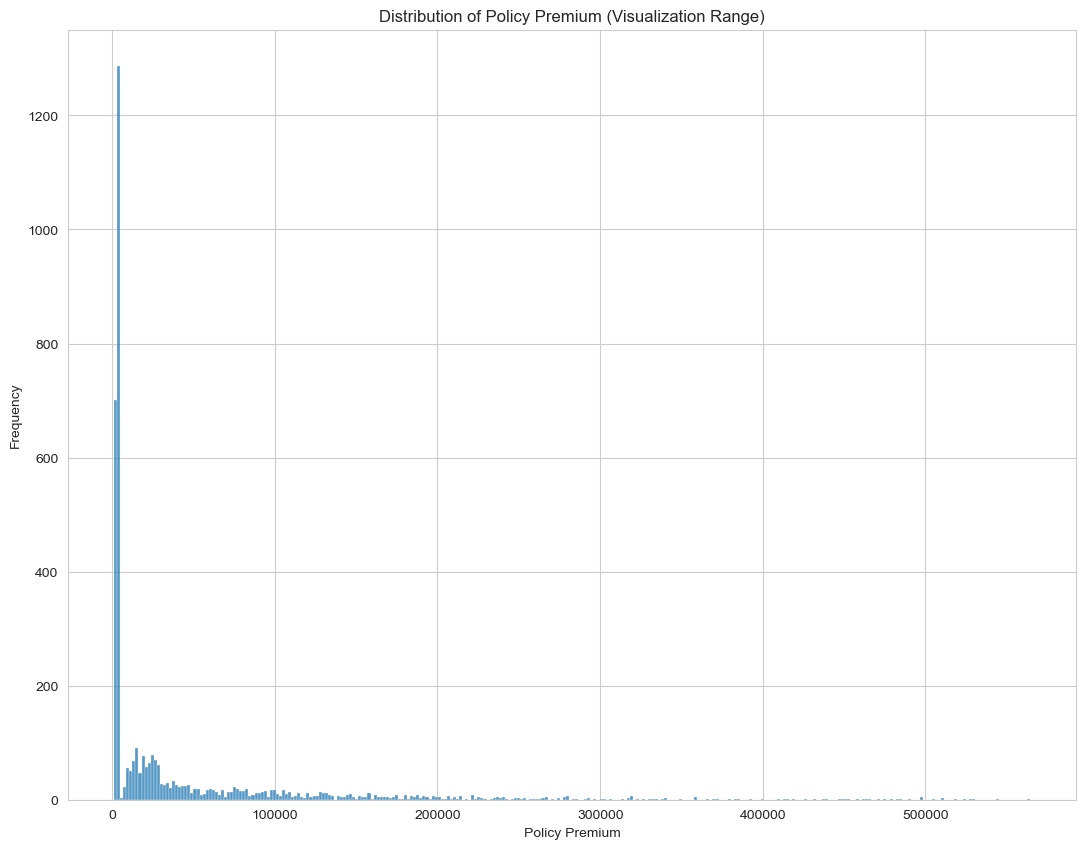

In [105]:
# Premium distribution

plt.figure(figsize=(13, 10))
sns.histplot(df_vis["POLICY PREMIUM"], bins=300)
plt.title("Distribution of Policy Premium (Visualization Range)")
plt.xlabel("Policy Premium")
plt.ylabel("Frequency")
plt.show()

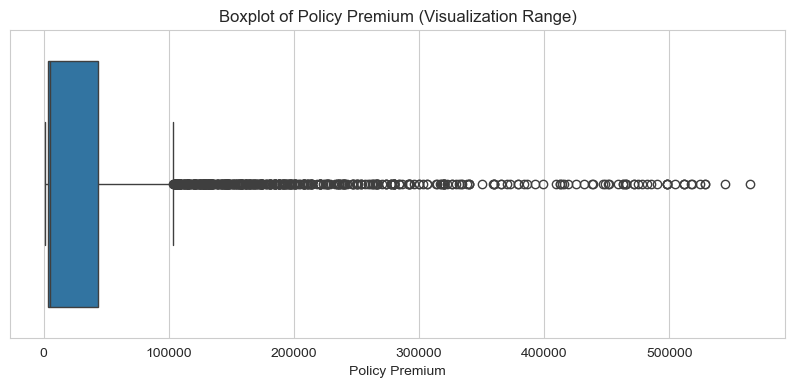

In [107]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_vis["POLICY PREMIUM"])
plt.title("Boxplot of Policy Premium (Visualization Range)")
plt.xlabel("Policy Premium")
plt.show()

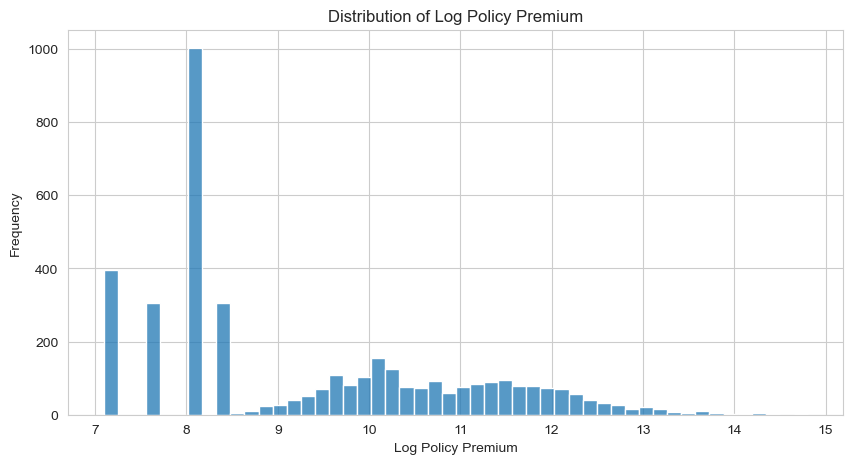

In [109]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["POLICY PREMIUM"]), bins=50)
plt.title("Distribution of Log Policy Premium")
plt.xlabel("Log Policy Premium")
plt.ylabel("Frequency")
plt.show()

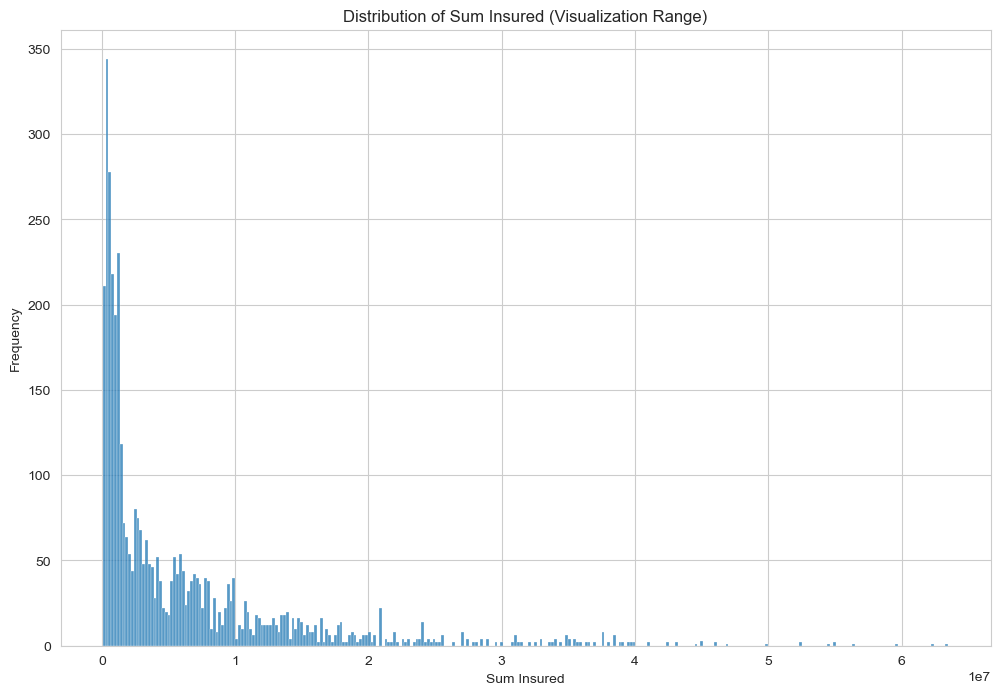

In [117]:
# Sum Insured Distribution

plt.figure(figsize=(12, 8))
sns.histplot(df_vis["SUM INSURED"], bins=300)
plt.title("Distribution of Sum Insured (Visualization Range)")
plt.xlabel("Sum Insured")
plt.ylabel("Frequency")
plt.show()

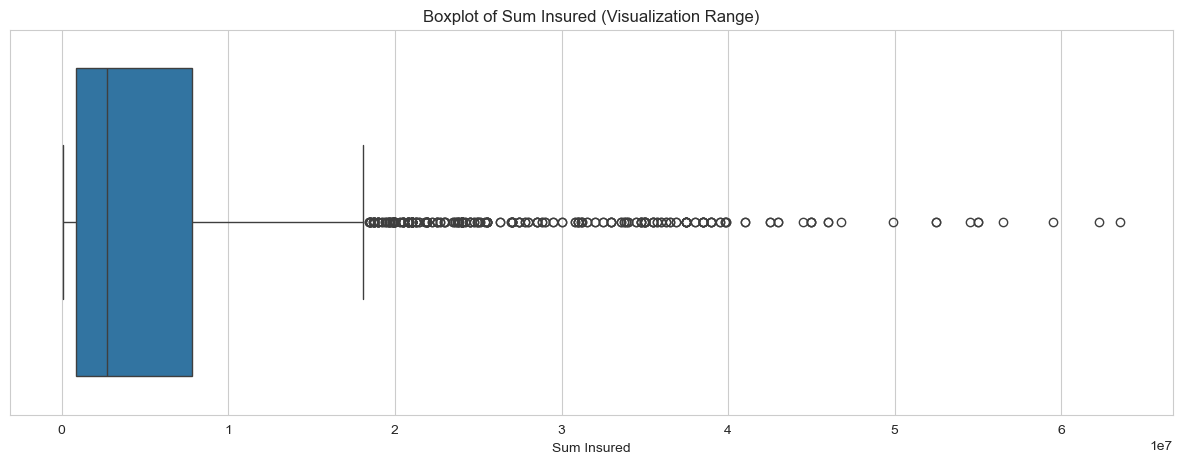

In [121]:
plt.figure(figsize=(15, 5))
sns.boxplot(x=df_vis["SUM INSURED"])
plt.title("Boxplot of Sum Insured (Visualization Range)")
plt.xlabel("Sum Insured")
plt.show()

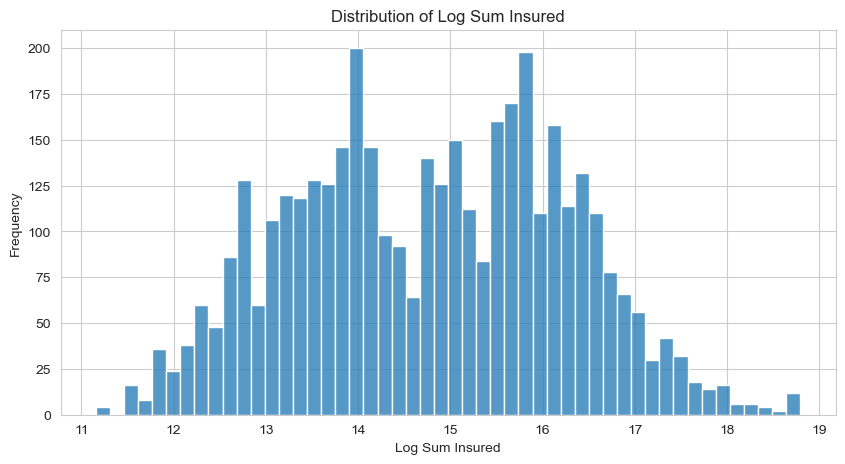

In [123]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["SUM INSURED"]), bins=50)
plt.title("Distribution of Log Sum Insured")
plt.xlabel("Log Sum Insured")
plt.ylabel("Frequency")
plt.show()

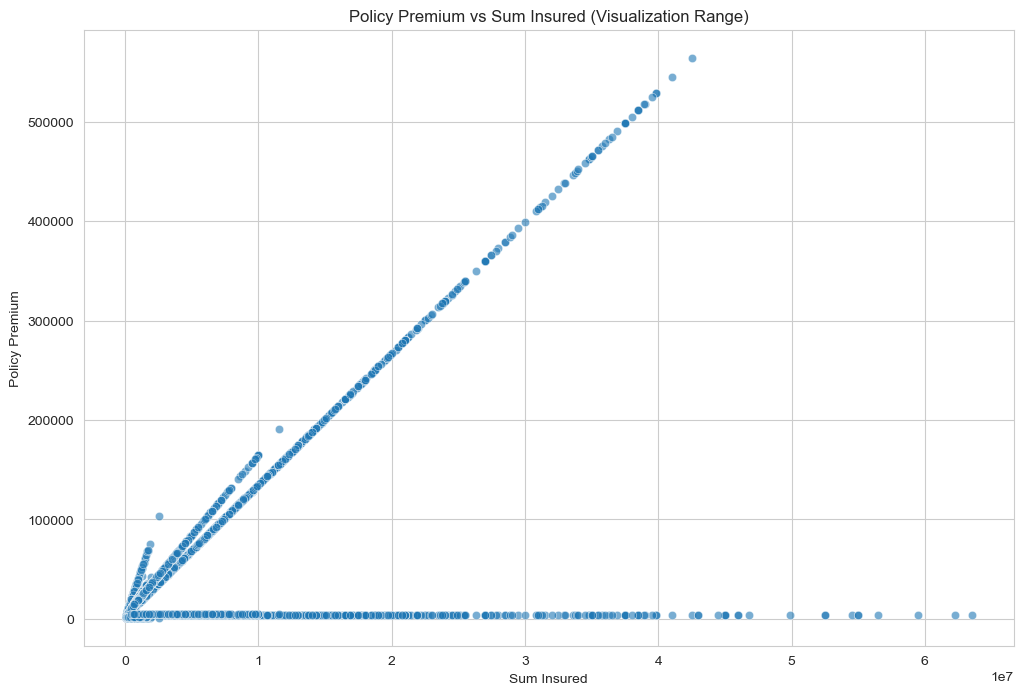

In [135]:
# Premium vs Sum Insured

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_vis, x="SUM INSURED", y="POLICY PREMIUM", alpha=0.6)
plt.title("Policy Premium vs Sum Insured (Visualization Range)")
plt.xlabel("Sum Insured")
plt.ylabel("Policy Premium")
plt.show()

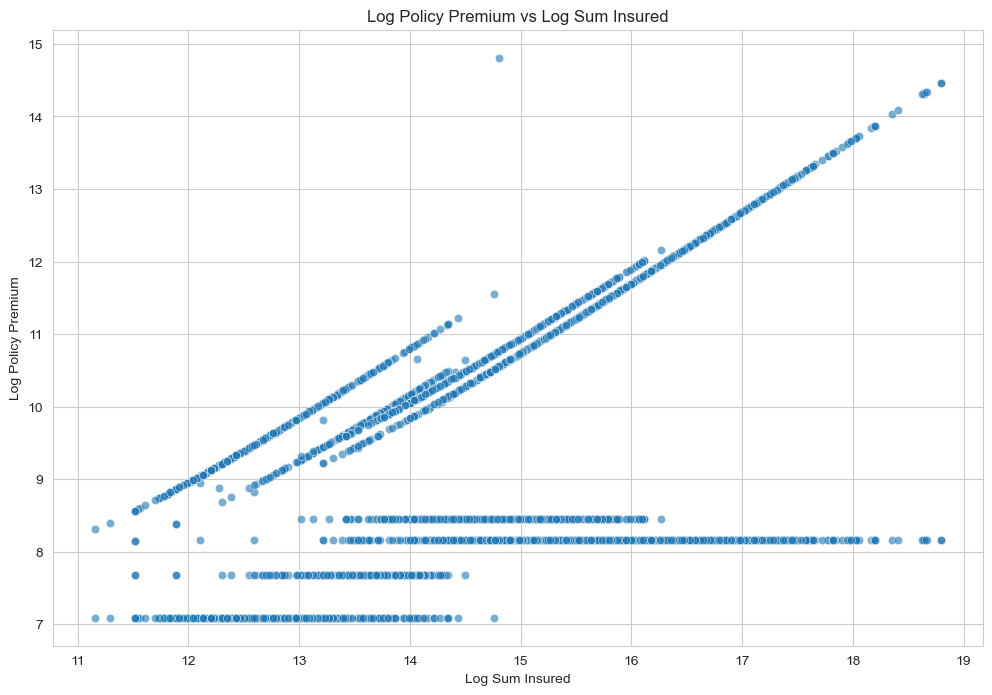

In [137]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=np.log1p(df["SUM INSURED"]),
    y=np.log1p(df["POLICY PREMIUM"]),
    alpha=0.6
)
plt.title("Log Policy Premium vs Log Sum Insured")
plt.xlabel("Log Sum Insured")
plt.ylabel("Log Policy Premium")
plt.show()

In [139]:
correlation = df[["SUM INSURED", "POLICY PREMIUM"]].corr()
correlation
print(f"Correlation between Sum Insured and Policy Premium: {correlation.loc['SUM INSURED', 'POLICY PREMIUM']:.4f}")

Correlation between Sum Insured and Policy Premium: 0.6180


In [141]:
# Premium by Insurance Type

insurance_type_summary = (
    df.groupby("INSURANCE TYPE")
      .agg(
          policy_count=("POLICY PREMIUM", "count"),
          avg_premium=("POLICY PREMIUM", "mean"),
          median_premium=("POLICY PREMIUM", "median"),
          avg_sum_insured=("SUM INSURED", "mean"),
          avg_premium_rate=("PREMIUM RATE", "mean"),
          median_premium_rate=("PREMIUM RATE", "median")
      )
      .sort_values(by="avg_premium", ascending=False)
)

insurance_type_summary

,policy_count,avg_premium,median_premium,avg_sum_insured,avg_premium_rate,median_premium_rate
INSURANCE TYPE,,,,,,
Comprehensive,1995,101244.189574,44625.41,7.002542e+06,0.022145,0.016623
Third Party,2003,3014.628058,3500.00,7.001797e+06,0.001886,0.001292


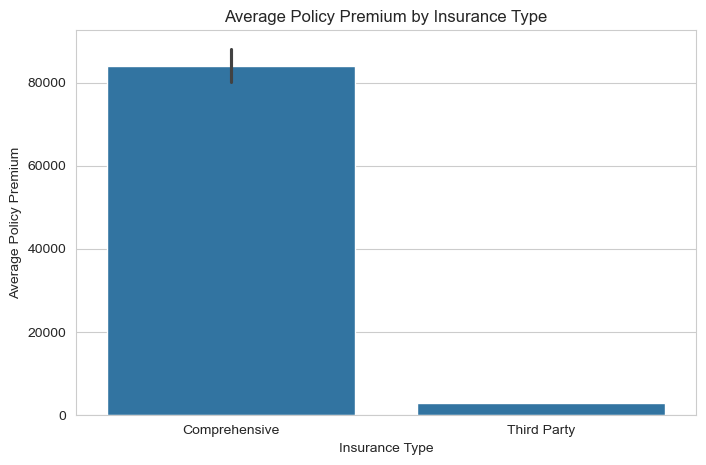

In [143]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_vis, x="INSURANCE TYPE", y="POLICY PREMIUM", estimator=np.mean)
plt.title("Average Policy Premium by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Average Policy Premium")
plt.show()

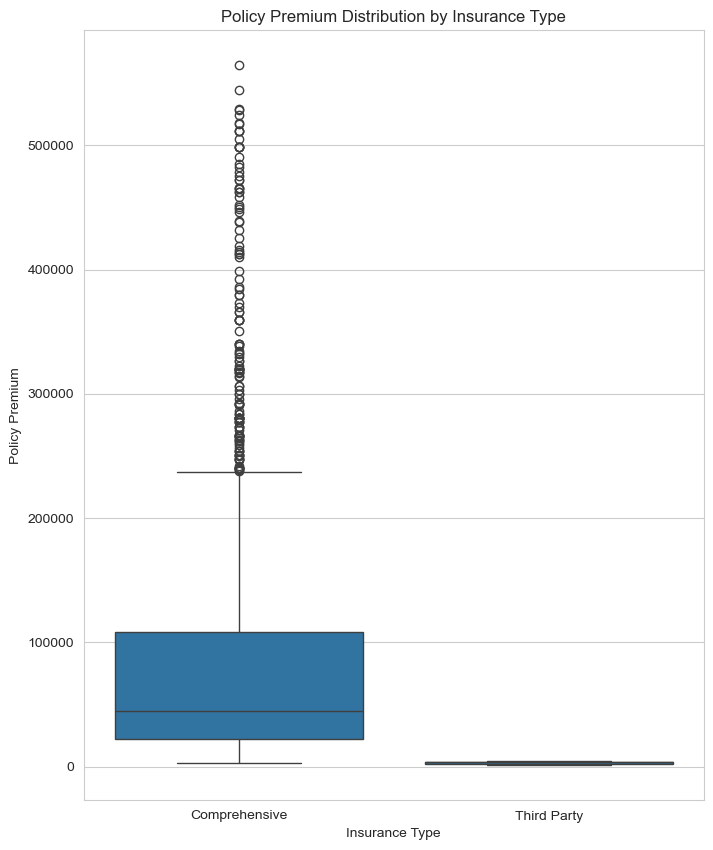

In [149]:
plt.figure(figsize=(8, 10))
sns.boxplot(data=df_vis, x="INSURANCE TYPE", y="POLICY PREMIUM")
plt.title("Policy Premium Distribution by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Policy Premium")
plt.show()

In [151]:
# Premium by Vehicle Type

vehicle_type_summary = (
    df.groupby("VEHICLE TYPE")
      .agg(
          policy_count=("POLICY PREMIUM", "count"),
          avg_premium=("POLICY PREMIUM", "mean"),
          median_premium=("POLICY PREMIUM", "median"),
          avg_sum_insured=("SUM INSURED", "mean"),
          avg_premium_rate=("PREMIUM RATE", "mean"),
          median_premium_rate=("PREMIUM RATE", "median"),
          avg_vehicle_age=("VEHICLE AGE", "mean")
      )
      .sort_values(by="avg_premium", ascending=False)
)

vehicle_type_summary

,policy_count,avg_premium,median_premium,avg_sum_insured,avg_premium_rate,median_premium_rate,avg_vehicle_age
VEHICLE TYPE,,,,,,,
Car,1998,87192.711026,3500.00,1.254260e+07,0.007775,0.012546,14.288288
van,1,63530.710000,63530.71,4.590000e+06,0.013841,0.013841,29.000000
Truck,1,35278.050000,35278.05,1.800000e+06,0.019599,0.019599,12.000000
Lorry,602,30943.872757,4650.00,3.319558e+06,0.010059,0.009817,18.892027
Three wheeler,606,11104.700594,2160.00,9.185413e+05,0.012609,0.018028,15.042904
Bike,790,10573.358038,1200.00,4.723377e+05,0.023660,0.016071,11.063291


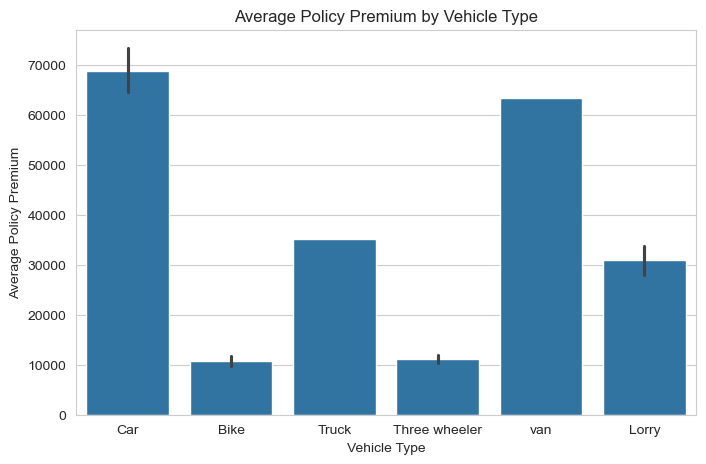

In [153]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_vis, x="VEHICLE TYPE", y="POLICY PREMIUM", estimator=np.mean)
plt.title("Average Policy Premium by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Policy Premium")
plt.show()

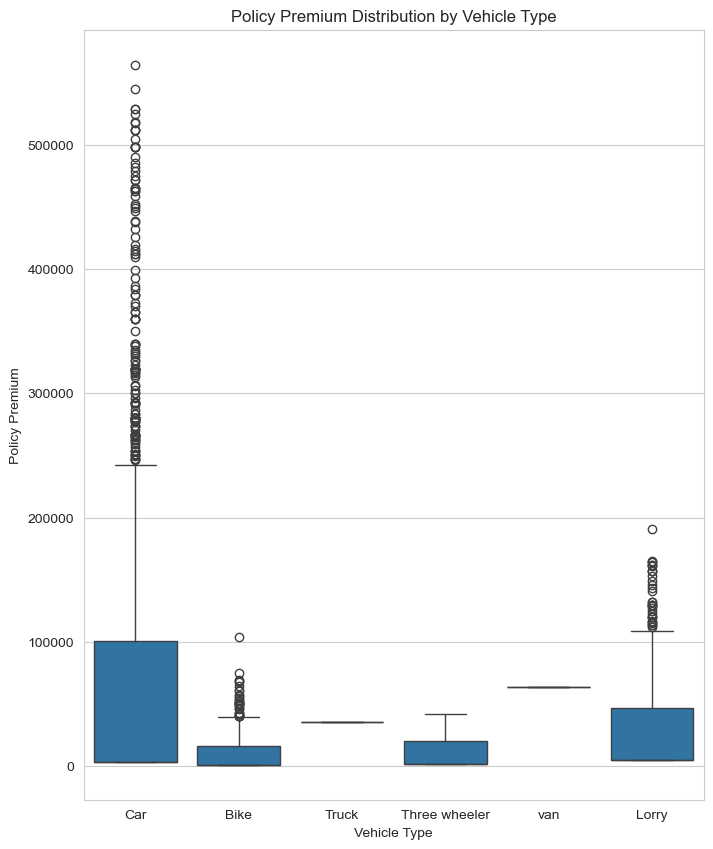

In [157]:
plt.figure(figsize=(8, 10))
sns.boxplot(data=df_vis, x="VEHICLE TYPE", y="POLICY PREMIUM")
plt.title("Policy Premium Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Policy Premium")
plt.show()

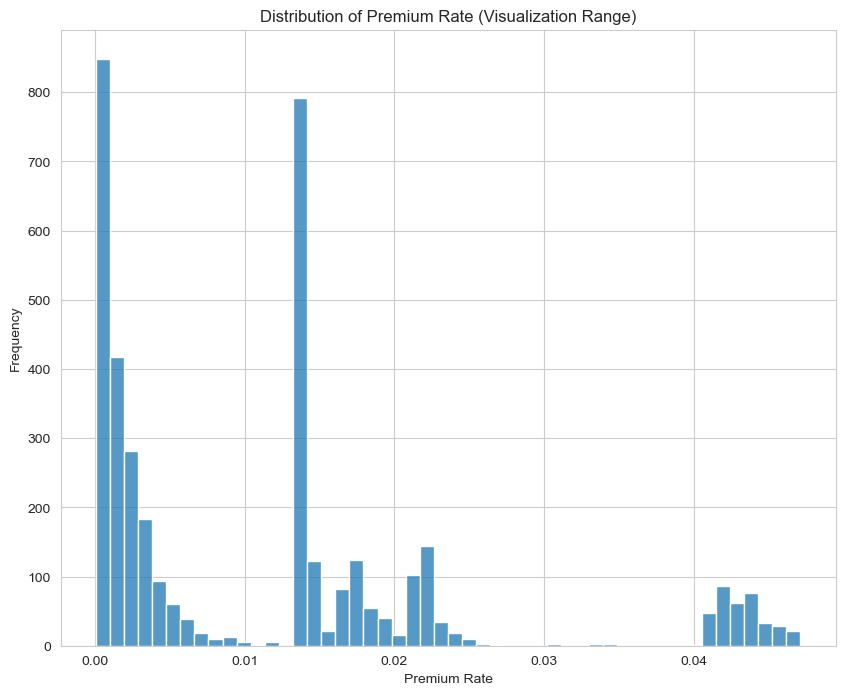

In [161]:
# Premium Rate Analysis

plt.figure(figsize=(10, 8))
sns.histplot(df_vis["PREMIUM RATE"], bins=50)
plt.title("Distribution of Premium Rate (Visualization Range)")
plt.xlabel("Premium Rate")
plt.ylabel("Frequency")
plt.show()

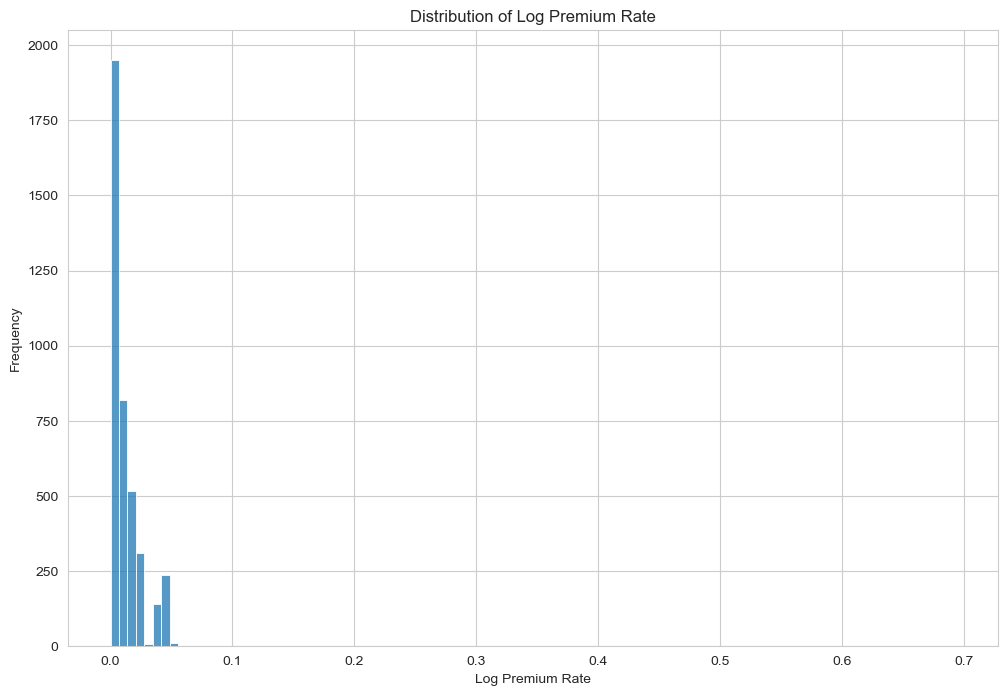

In [169]:
plt.figure(figsize=(12, 8))
sns.histplot(np.log1p(df["PREMIUM RATE"]), bins=100)
plt.title("Distribution of Log Premium Rate")
plt.xlabel("Log Premium Rate")
plt.ylabel("Frequency")
plt.show()

In [171]:
premium_rate_by_insurance = (
    df.groupby("INSURANCE TYPE")
      .agg(
          avg_premium_rate=("PREMIUM RATE", "mean"),
          median_premium_rate=("PREMIUM RATE", "median")
      )
      .sort_values(by="avg_premium_rate", ascending=False)
)

premium_rate_by_insurance

,avg_premium_rate,median_premium_rate
INSURANCE TYPE,,
Comprehensive,0.022145,0.016623
Third Party,0.001886,0.001292


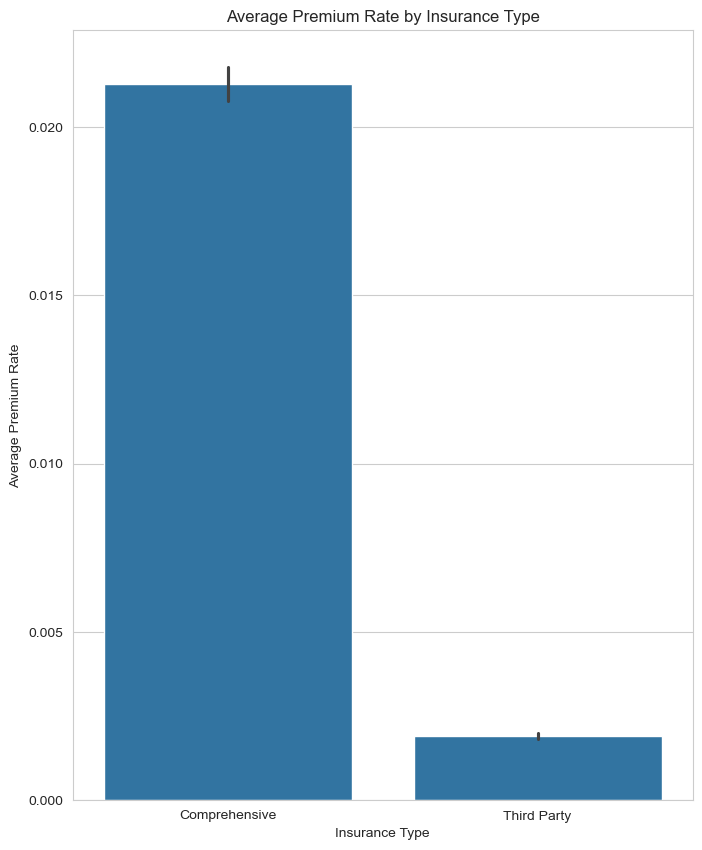

In [175]:
plt.figure(figsize=(8, 10))
sns.barplot(data=df_vis, x="INSURANCE TYPE", y="PREMIUM RATE", estimator=np.mean)
plt.title("Average Premium Rate by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Average Premium Rate")
plt.show()

In [177]:
premium_rate_by_vehicle = (
    df.groupby("VEHICLE TYPE")
      .agg(
          avg_premium_rate=("PREMIUM RATE", "mean"),
          median_premium_rate=("PREMIUM RATE", "median")
      )
      .sort_values(by="avg_premium_rate", ascending=False)
)

premium_rate_by_vehicle

,avg_premium_rate,median_premium_rate
VEHICLE TYPE,,
Bike,0.023660,0.016071
Truck,0.019599,0.019599
van,0.013841,0.013841
Three wheeler,0.012609,0.018028
Lorry,0.010059,0.009817
Car,0.007775,0.012546


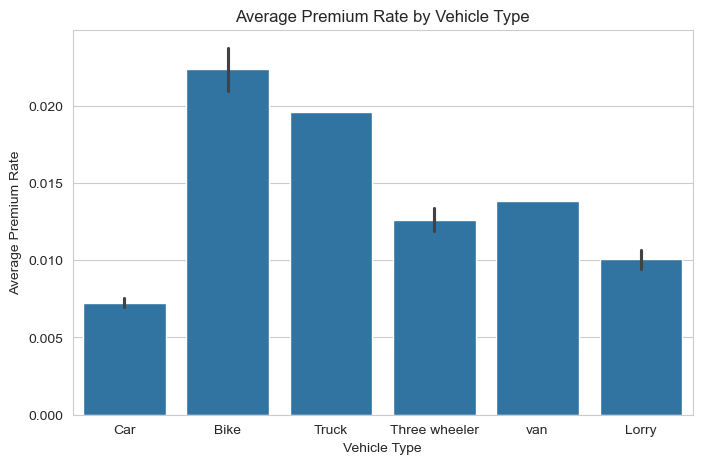

In [179]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_vis, x="VEHICLE TYPE", y="PREMIUM RATE", estimator=np.mean)
plt.title("Average Premium Rate by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Premium Rate")
plt.show()

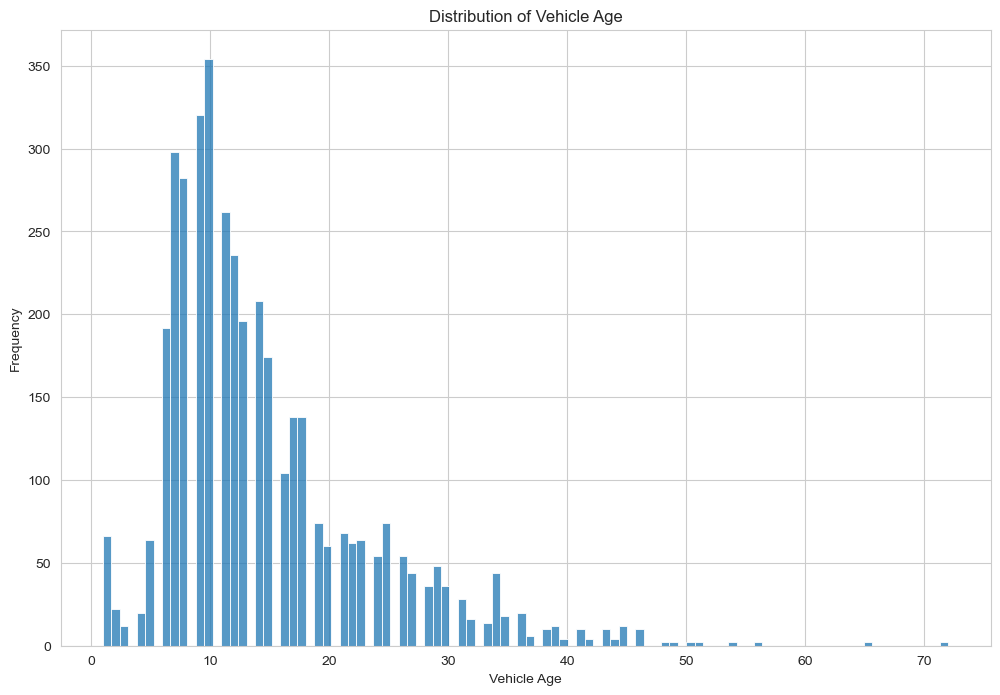

In [185]:
# Vehicle Age Analysis

plt.figure(figsize=(12, 8))
sns.histplot(df["VEHICLE AGE"], bins=100)
plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Frequency")
plt.show()

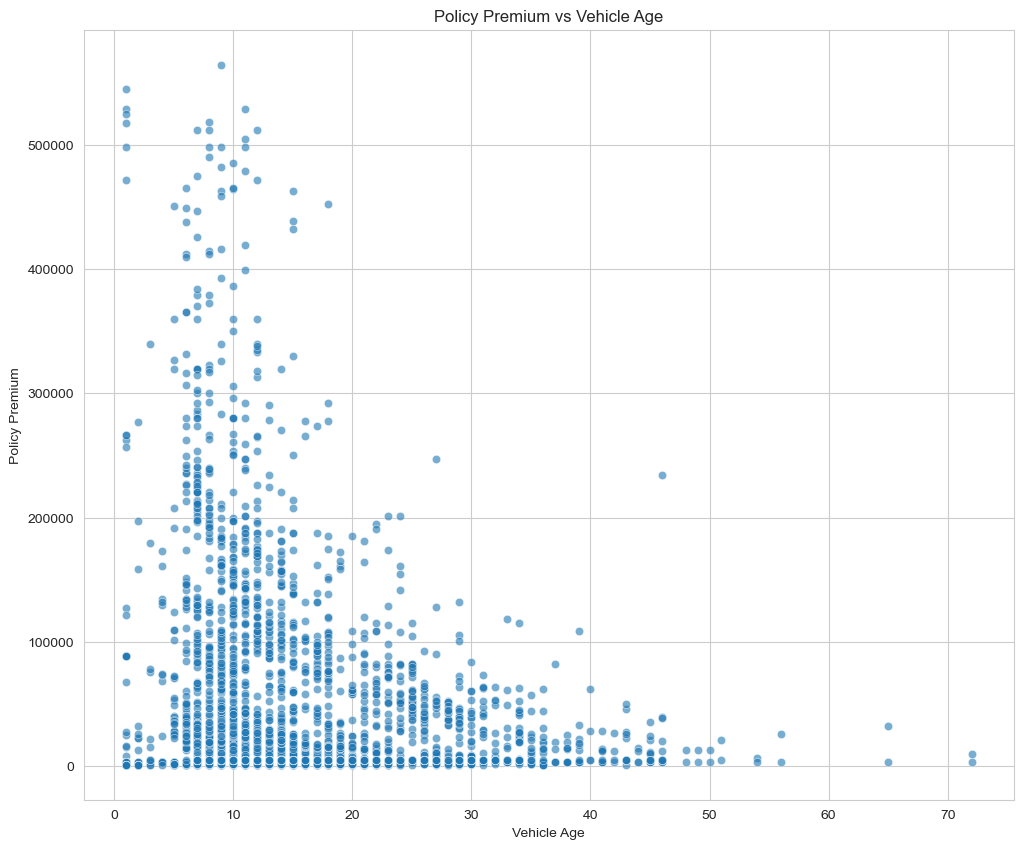

In [189]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=df_vis, x="VEHICLE AGE", y="POLICY PREMIUM", alpha=0.6)
plt.title("Policy Premium vs Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Policy Premium")
plt.show()

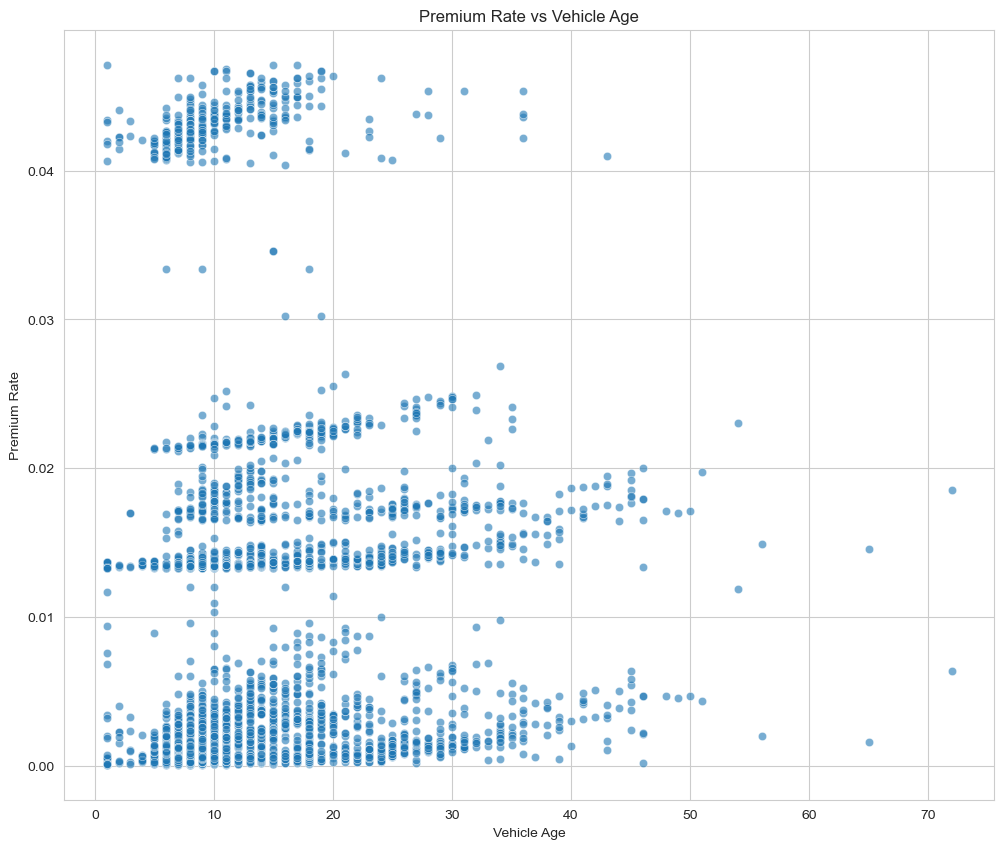

In [191]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=df_vis, x="VEHICLE AGE", y="PREMIUM RATE", alpha=0.6)
plt.title("Premium Rate vs Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Premium Rate")
plt.show()

In [193]:
# Create vehicle age bands

df["VEHICLE AGE BAND"] = pd.cut(
    df["VEHICLE AGE"],
    bins=[-1, 3, 7, 12, 100],
    labels=["0-3 Years", "4-7 Years", "8-12 Years", "13+ Years"]
)

In [195]:
df_vis = df[
    (df["POLICY PREMIUM"] <= premium_cap) &
    (df["SUM INSURED"] <= sum_insured_cap) &
    (df["PREMIUM RATE"] <= premium_rate_cap)
].copy()

In [197]:
vehicle_age_band_summary = (
    df.groupby("VEHICLE AGE BAND", observed=False)
      .agg(
          policy_count=("POLICY PREMIUM", "count"),
          avg_premium=("POLICY PREMIUM", "mean"),
          median_premium=("POLICY PREMIUM", "median"),
          avg_sum_insured=("SUM INSURED", "mean"),
          avg_premium_rate=("PREMIUM RATE", "mean")
      )
      .sort_values(by="avg_premium", ascending=False)
)

vehicle_age_band_summary

,policy_count,avg_premium,median_premium,avg_sum_insured,avg_premium_rate
VEHICLE AGE BAND,,,,,
0-3 Years,100,197233.436400,5012.185,2.911490e+07,0.012389
4-7 Years,574,78560.335122,4650.000,1.103115e+07,0.012756
8-12 Years,1454,57207.042455,4650.000,7.884025e+06,0.011399
13+ Years,1870,32098.632337,4650.000,3.897289e+06,0.012203


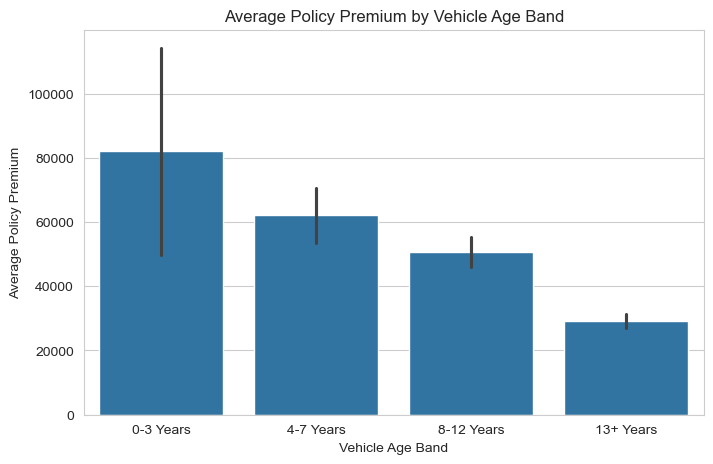

In [199]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_vis, x="VEHICLE AGE BAND", y="POLICY PREMIUM", estimator=np.mean)
plt.title("Average Policy Premium by Vehicle Age Band")
plt.xlabel("Vehicle Age Band")
plt.ylabel("Average Policy Premium")
plt.show()

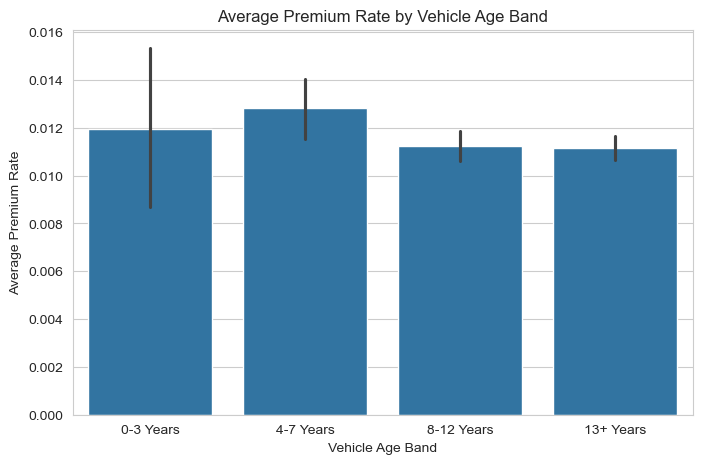

In [201]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_vis, x="VEHICLE AGE BAND", y="PREMIUM RATE", estimator=np.mean)
plt.title("Average Premium Rate by Vehicle Age Band")
plt.xlabel("Vehicle Age Band")
plt.ylabel("Average Premium Rate")
plt.show()

In [203]:
# Top Vehicle Makes by Average Premium

top_makes = df["VEHICLE MAKE"].value_counts().head(10).index
df_top_makes = df[df["VEHICLE MAKE"].isin(top_makes)].copy()

In [205]:
make_summary = (
    df_top_makes.groupby("VEHICLE MAKE")
    .agg(
        policy_count=("POLICY PREMIUM", "count"),
        avg_premium=("POLICY PREMIUM", "mean"),
        median_premium=("POLICY PREMIUM", "median"),
        avg_sum_insured=("SUM INSURED", "mean"),
        avg_premium_rate=("PREMIUM RATE", "mean")
    )
    .sort_values(by="avg_premium", ascending=False)
)

make_summary

,policy_count,avg_premium,median_premium,avg_sum_insured,avg_premium_rate
VEHICLE MAKE,,,,,
Mitsubishi,102,84777.815882,7496.305,1.235490e+07,0.007427
Toyota,592,83213.461774,5726.930,1.143658e+07,0.008890
Honda,216,77761.905694,3500.000,1.129231e+07,0.007202
Nissan,158,45046.423544,6835.980,6.338481e+06,0.007777
Isuzu,112,44294.432321,12325.885,4.964911e+06,0.009319
Suzuki,274,34935.802847,11293.790,4.808285e+06,0.007417
Tata,132,21003.241439,9705.455,2.076212e+06,0.010685
Honda,160,12294.288688,3228.400,5.549562e+05,0.022976
Bajaj,866,10278.555958,2811.385,7.329652e+05,0.016554


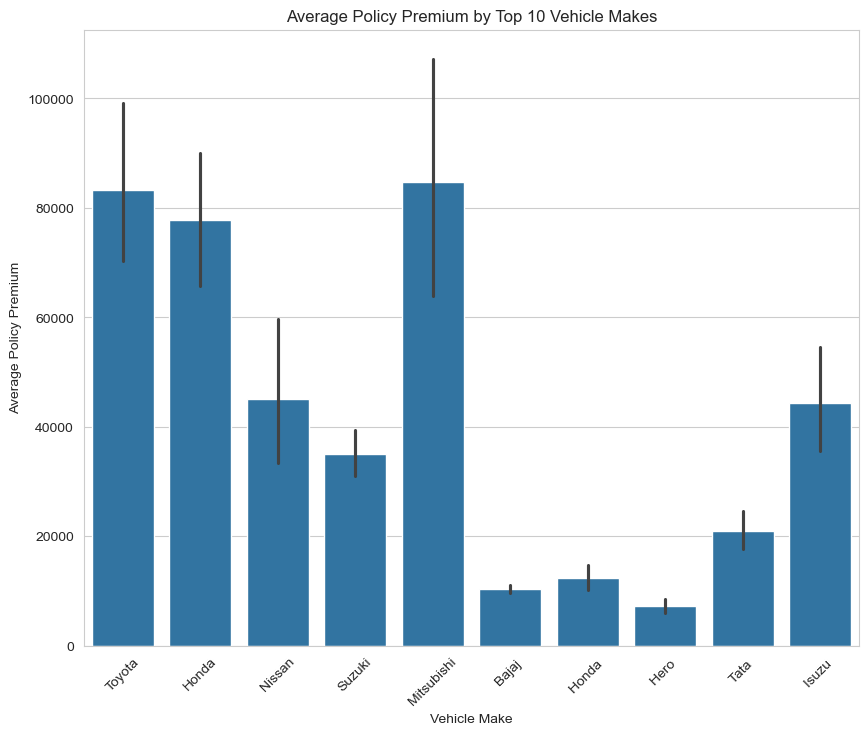

In [209]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_top_makes, x="VEHICLE MAKE", y="POLICY PREMIUM", estimator=np.mean)
plt.title("Average Policy Premium by Top 10 Vehicle Makes")
plt.xlabel("Vehicle Make")
plt.ylabel("Average Policy Premium")
plt.xticks(rotation=45)
plt.show()

In [211]:
# Top Vehicle Models by Average Premium

top_models = df["VEHICLE MODEL"].value_counts().head(10).index
df_top_models = df[df["VEHICLE MODEL"].isin(top_models)].copy()

In [213]:
model_summary = (
    df_top_models.groupby("VEHICLE MODEL")
    .agg(
        policy_count=("POLICY PREMIUM", "count"),
        avg_premium=("POLICY PREMIUM", "mean"),
        median_premium=("POLICY PREMIUM", "median"),
        avg_sum_insured=("SUM INSURED", "mean"),
        avg_premium_rate=("PREMIUM RATE", "mean")
    )
    .sort_values(by="avg_premium", ascending=False)
)

model_summary

,policy_count,avg_premium,median_premium,avg_sum_insured,avg_premium_rate
VEHICLE MODEL,,,,,
Vezel,52,88464.945769,66600.515,1.291327e+07,0.006859
Vitz,72,55097.873472,37213.865,7.859028e+06,0.007033
Elf,70,43807.924714,12325.885,4.904571e+06,0.009321
Canter,68,39545.175000,16357.320,4.375882e+06,0.009281
Corolla,74,27758.936486,7760.735,3.720000e+06,0.008184
Alto,74,25112.376081,18062.480,3.320081e+06,0.007620
Sunny,54,20944.612963,6835.980,2.687593e+06,0.008372
Dio,88,11404.109091,3228.400,5.102841e+05,0.022928
RE,578,11147.775606,2811.385,9.156851e+05,0.012700


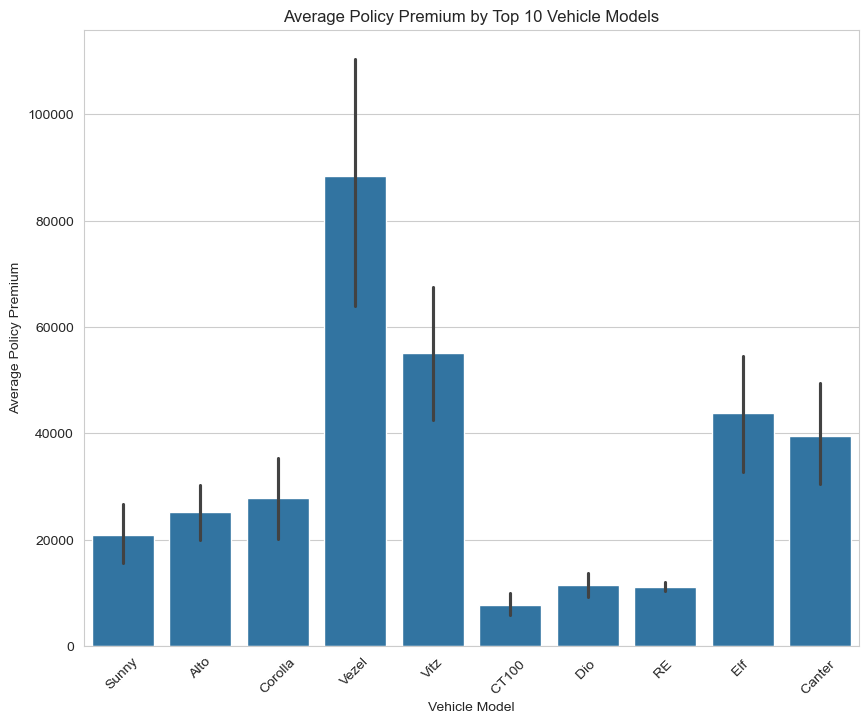

In [217]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_top_models, x="VEHICLE MODEL", y="POLICY PREMIUM", estimator=np.mean)
plt.title("Average Policy Premium by Top 10 Vehicle Models")
plt.xlabel("Vehicle Model")
plt.ylabel("Average Policy Premium")
plt.xticks(rotation=45)
plt.show()

In [219]:
# Cross-segmentation: Insurance Type × Vehicle Type

cross_segment_summary = (
    df.groupby(["INSURANCE TYPE", "VEHICLE TYPE"])
      .agg(
          policy_count=("POLICY PREMIUM", "count"),
          avg_premium=("POLICY PREMIUM", "mean"),
          median_premium=("POLICY PREMIUM", "median"),
          avg_sum_insured=("SUM INSURED", "mean"),
          avg_premium_rate=("PREMIUM RATE", "mean")
      )
      .reset_index()
      .sort_values(by="avg_premium", ascending=False)
)

cross_segment_summary

,INSURANCE TYPE,VEHICLE TYPE,policy_count,avg_premium,median_premium,avg_sum_insured,avg_premium_rate
1,Comprehensive,Car,998,171053.142916,105927.380,1.253112e+07,0.014821
5,Comprehensive,van,1,63530.710000,63530.710,4.590000e+06,0.013841
2,Comprehensive,Lorry,300,57413.038000,47093.005,3.319973e+06,0.017966
4,Comprehensive,Truck,1,35278.050000,35278.050,1.800000e+06,0.019599
3,Comprehensive,Three wheeler,301,20168.267641,20325.950,9.172857e+05,0.022390
0,Comprehensive,Bike,394,19994.296574,15877.860,4.708716e+05,0.043719
8,Third Party,Lorry,302,4650.000000,4650.000,3.319145e+06,0.002205
7,Third Party,Car,1000,3500.000000,3500.000,1.255406e+07,0.000743
9,Third Party,Three wheeler,305,2160.000000,2160.000,9.197803e+05,0.002956
6,Third Party,Bike,396,1200.000000,1200.000,4.737965e+05,0.003703


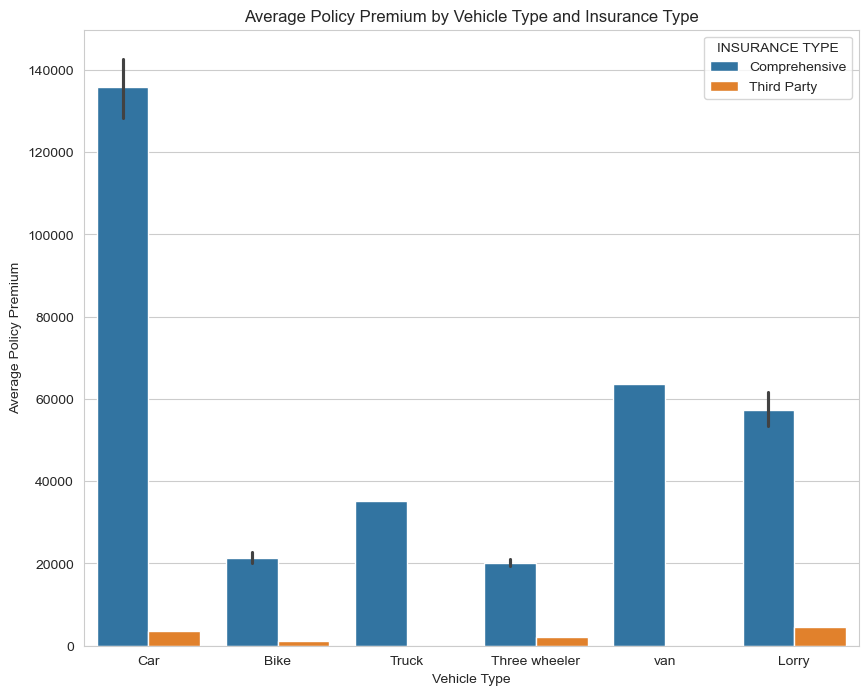

In [223]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_vis, x="VEHICLE TYPE", y="POLICY PREMIUM", hue="INSURANCE TYPE", estimator=np.mean)
plt.title("Average Policy Premium by Vehicle Type and Insurance Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Policy Premium")
plt.show()

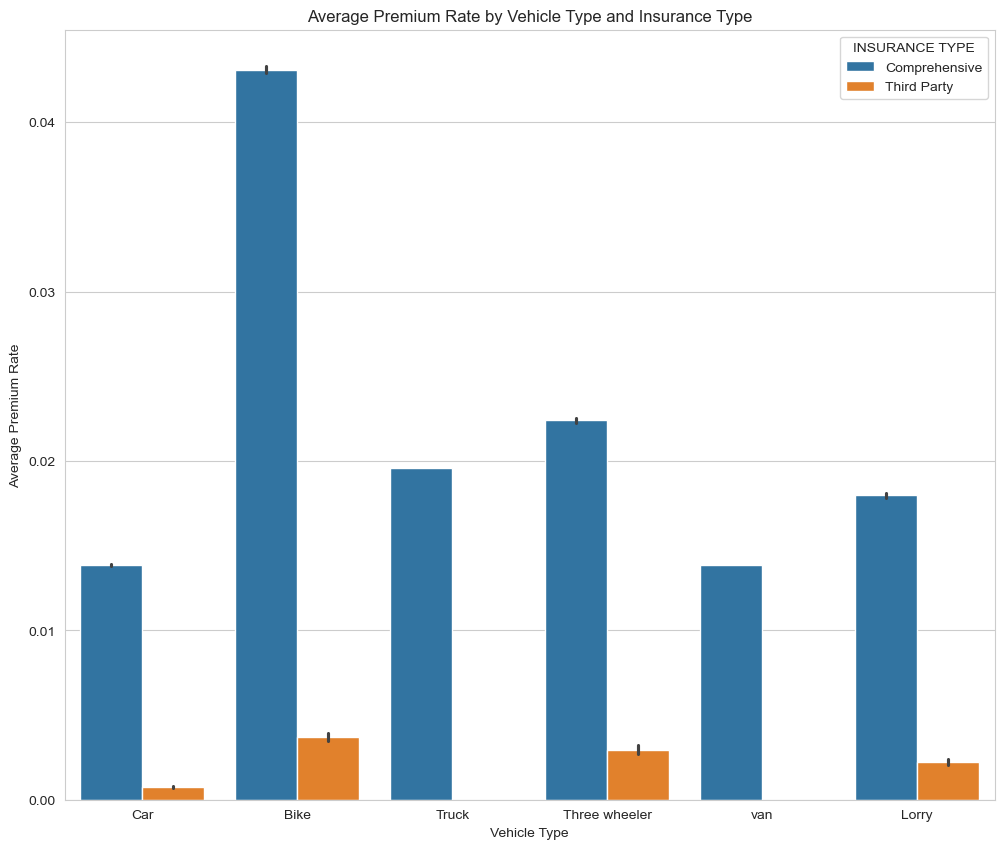

In [227]:
plt.figure(figsize=(12, 10))
sns.barplot(data=df_vis, x="VEHICLE TYPE", y="PREMIUM RATE", hue="INSURANCE TYPE", estimator=np.mean)
plt.title("Average Premium Rate by Vehicle Type and Insurance Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Premium Rate")
plt.show()

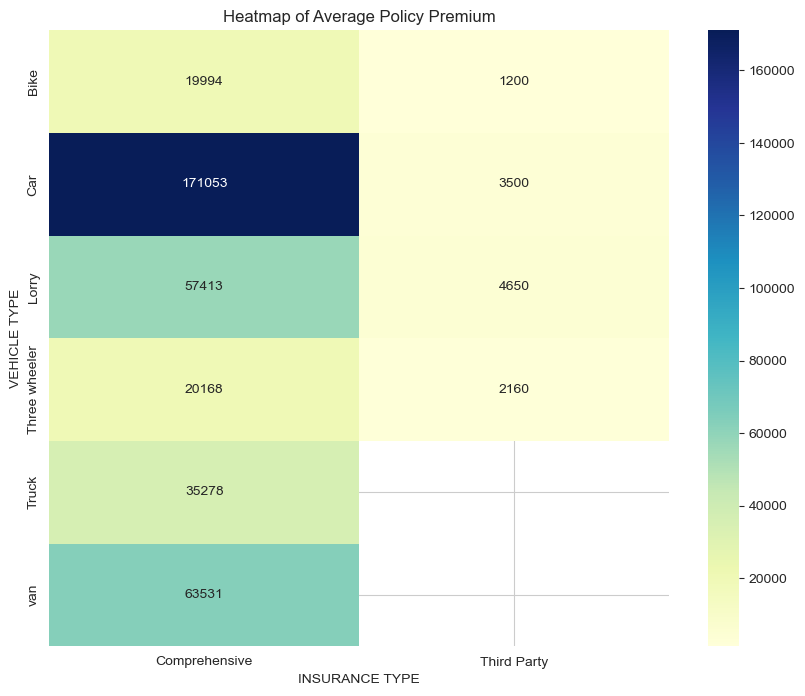

In [233]:
# Heatmap of average premium

heatmap_data = df.pivot_table(
    values="POLICY PREMIUM",
    index="VEHICLE TYPE",
    columns="INSURANCE TYPE",
    aggfunc="mean"
)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of Average Policy Premium")
plt.show()

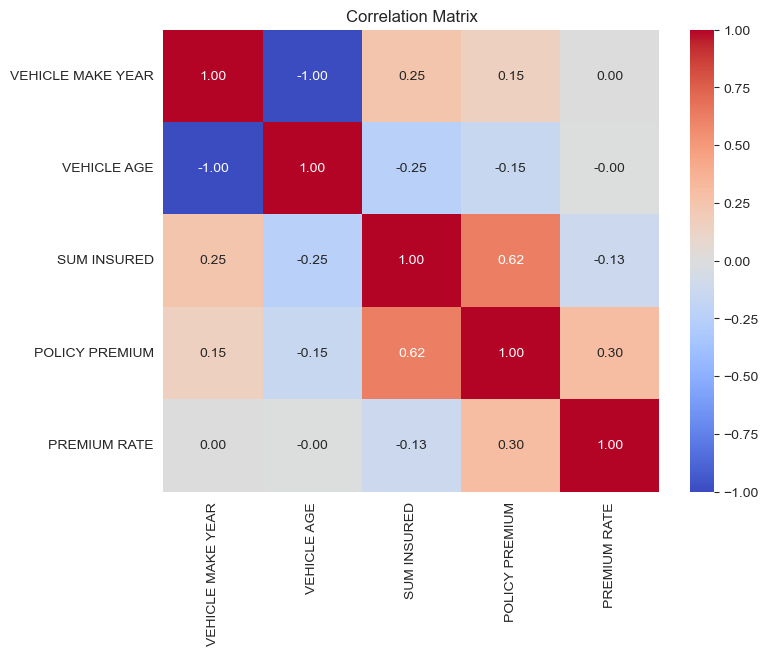

In [235]:
numeric_cols = [
    "VEHICLE MAKE YEAR",
    "VEHICLE AGE",
    "SUM INSURED",
    "POLICY PREMIUM",
    "PREMIUM RATE"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [237]:
segment_ranking = (
    df.groupby(["INSURANCE TYPE", "VEHICLE TYPE", "VEHICLE AGE BAND"])
      .agg(
          policy_count=("POLICY PREMIUM", "count"),
          avg_premium=("POLICY PREMIUM", "mean"),
          median_premium=("POLICY PREMIUM", "median"),
          avg_premium_rate=("PREMIUM RATE", "mean"),
          avg_sum_insured=("SUM INSURED", "mean")
      )
      .reset_index()
      .sort_values(by="avg_premium", ascending=False)
)

segment_ranking.head(10)

/var/folders/dh/vh_kvsnj41q6877kxnwy1c040000gn/T/ipykernel_8395/4176938015.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["INSURANCE TYPE", "VEHICLE TYPE", "VEHICLE AGE BAND"])


,INSURANCE TYPE,VEHICLE TYPE,VEHICLE AGE BAND,policy_count,avg_premium,median_premium,avg_premium_rate,avg_sum_insured
4,Comprehensive,Car,0-3 Years,32,596711.450625,484987.100,0.013354,4.496297e+07
5,Comprehensive,Car,4-7 Years,158,254071.777911,207791.665,0.013508,1.901813e+07
6,Comprehensive,Car,8-12 Years,377,186048.199019,144230.140,0.013642,1.386857e+07
7,Comprehensive,Car,13+ Years,431,95899.671160,64653.410,0.016442,6.575248e+06
8,Comprehensive,Lorry,0-3 Years,2,76844.980000,76844.980,0.016983,4.525000e+06
9,Comprehensive,Lorry,4-7 Years,11,73326.640909,66766.400,0.017303,4.306818e+06
23,Comprehensive,van,13+ Years,1,63530.710000,63530.710,0.013841,4.590000e+06
11,Comprehensive,Lorry,13+ Years,192,57062.981771,47415.520,0.017976,3.298265e+06
10,Comprehensive,Lorry,8-12 Years,95,55868.798842,42577.800,0.018043,3.224211e+06
18,Comprehensive,Truck,8-12 Years,1,35278.050000,35278.050,0.019599,1.800000e+06


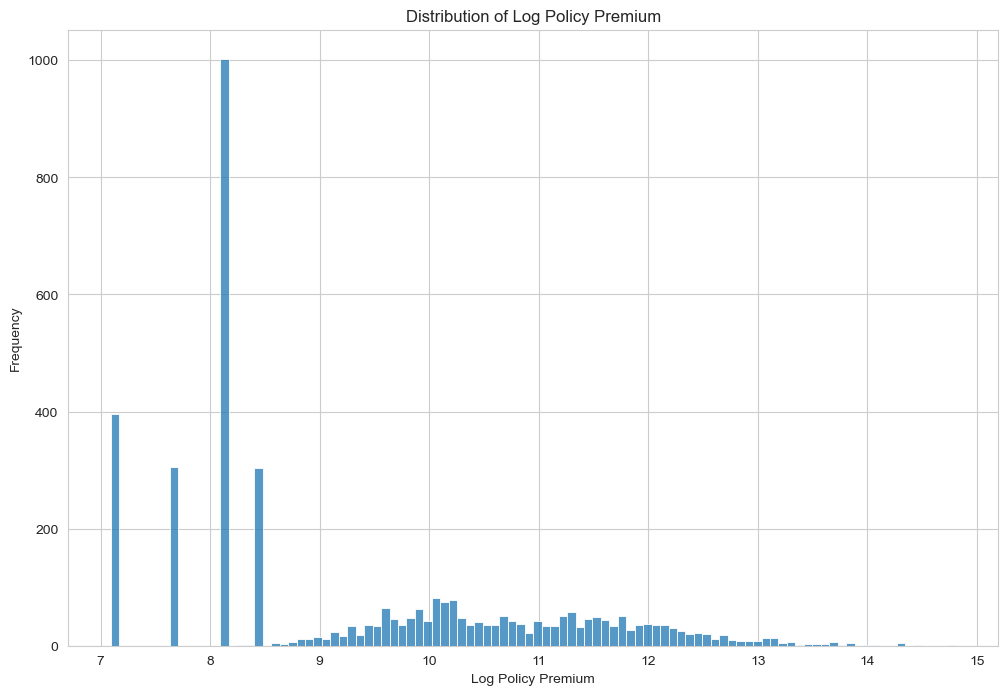

In [241]:
df["LOG POLICY PREMIUM"] = np.log1p(df["POLICY PREMIUM"])

plt.figure(figsize=(12, 8))
sns.histplot(df["LOG POLICY PREMIUM"], bins=100)
plt.title("Distribution of Log Policy Premium")
plt.xlabel("Log Policy Premium")
plt.ylabel("Frequency")
plt.show()